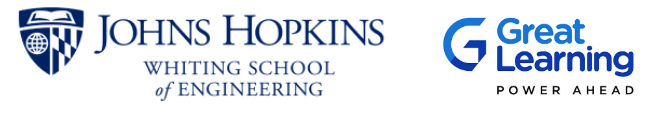

<font size=6>**Developing Agents with LangChain/LangGraph**</font>

<font size=5>**News Discovery Agent**</font>

##<font color=blue> **Business Problem - NewsFindr: AI-Powered Personalized News Discovery Agent**

NewsFindr is redefining news discovery by delivering real-time news updates tailored to user interests. Traditional search methods and generic news feeds often lead to information overload and inefficiencies, making it challenging for users to access relevant and trustworthy content efficiently.

To address this, NewsFindr leverages LangGraph agentic flow to build an AI-powered news retrieval agent that ensures accuracy and credibility. By utilizing this structured, multi-step approach, the system will provide secure, fair, and explainable recommendations—enhancing user engagement, optimizing content discovery, and improving access to timely and relevant news.

##<font color=blue>**Business Impact**
✔ **Personalized News Experience** – Delivers real-time, relevant news tailored to user interests.

✔ **Time Efficiency** – Eliminates manual searches, ensuring instant access to the latest updates.

✔ **Trust & Transparency** – Ensures accuracy, credibility, and fairness in AI-driven news recommendations.

##<font color=blue>**Objective**

🔹 **Provide real-time, personalized news retrieval** to help users discover relevant content effortlessly.

🔹 **Ensure accuracy and credibility** by sourcing news from trusted platforms and minimizing misinformation.

🔹 **Improve user engagement** through seamless content discovery, reducing information overload.

🔹 **Streamline the news consumption process** by eliminating outdated and irrelevant content, providing a refined reading experience.

##**<font color=blue>Solution Approach for "News Discovery Agent"**

<font color=Magenta>Verify User Email</font>: Check if the user's email exists in the database. If invalid, collect and store user details for future use.

<font color=Magenta>Display User Interests</font>: Retrieve and present user preferences to personalize news recommendations.

<font color=Magenta>Generate Search Queries</font>: Construct optimized search queries based on user interests to ensure relevant results.

<font color=Magenta>Retrieve Search Results</font>: Fetch real-time news articles links from multiple trusted sources.

<font color=Magenta>Extract Relevant Links</font>: Filter and select the most relevant articles aligned with the user’s topics of interest.

<font color=Magenta>Validate Authentic Sources</font>: Ensure credibility by verifying the source authority and filtering out low-quality or fake news sites.

<font color=Magenta>Provide Authenticated Links to Users</font>: Deliver only verified and high-quality news links, ensuring reliability and credibility in recommendations.

<font color=Magenta>Deploy the Agent for Members and New Users</font>: Deploy the AI-powered news retrieval agent accessible to both registered users and new members to generate interest based authenticated news links.

###🔹<font color=blue>**Optional Advanced Content**</font>

<font color=Magenta>Extract, Summarize, and Proofread Content</font>: Apply NLP techniques to generate concise, accurate summaries while maintaining content integrity.

<font color=Magenta>Provide Authenticated Links and News Summary to Users</font>: Deliver only verified and high-quality news links, ensuring reliability and credibility in recommendations.

<font color=Magenta>Deploy the Agent for Members and New Users</font>: Deploy the AI-powered news retrieval agent accessible to both registered users and new members to generate interest based authenticated news links and summary.

##**<font color=blue>Solution Workflow for "News Discovery Agent"**

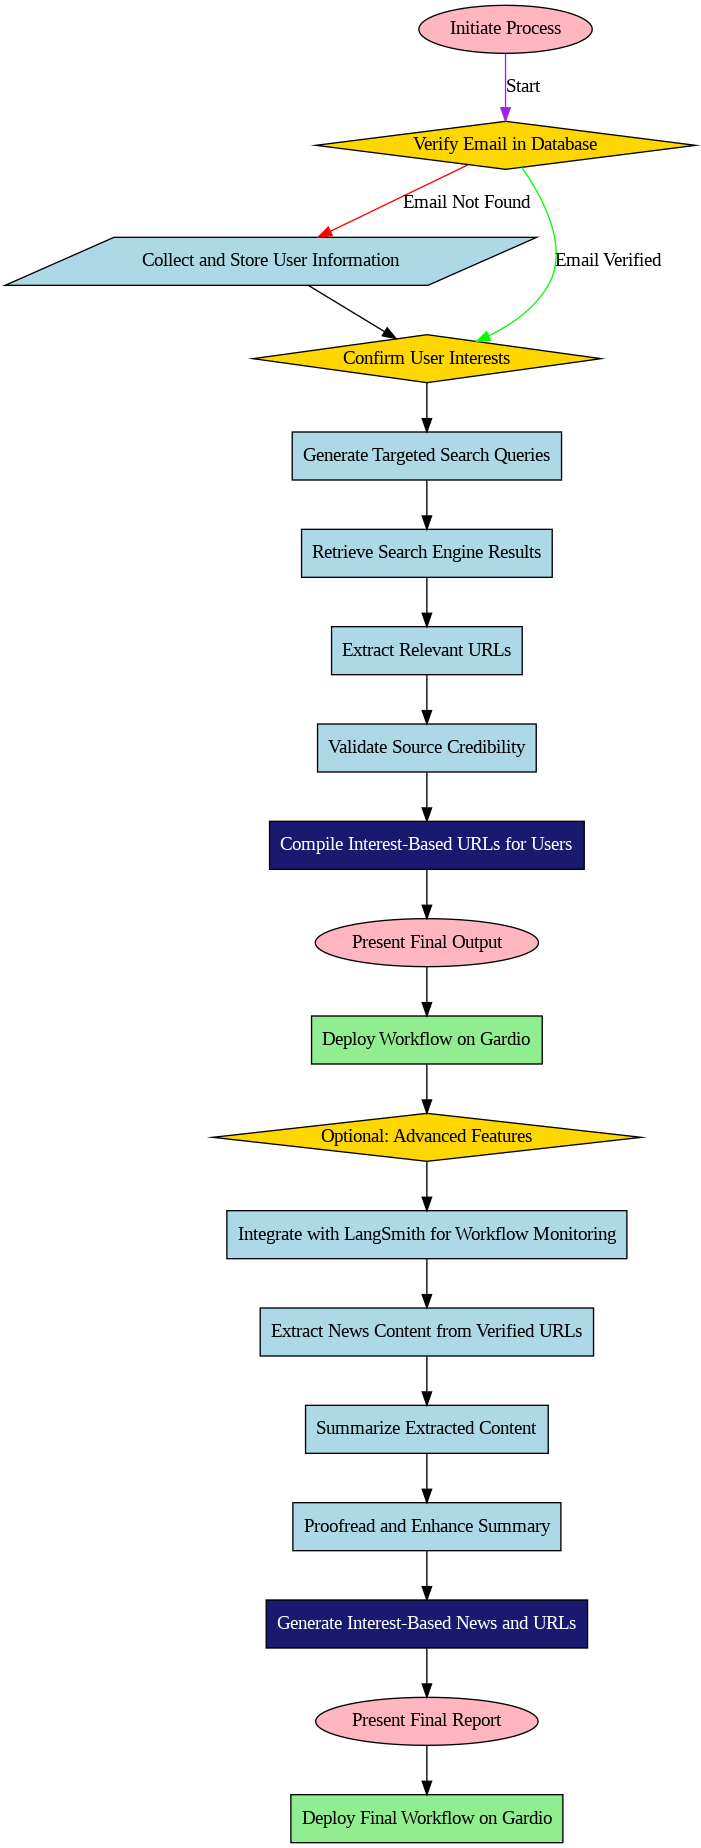

##**<font color=blue>Library Installation and LLM Calling**

In [ ]:
!pip install -q \
  "langchain-core>=0.3.58,<1.0.0" \
  "langchain==0.3.25" \
  "langchain-openai==0.3.35" \
  "langchain-community==0.3.24" \
  "langchain-experimental==0.3.4" \
  "langchain-chroma" \
  "langgraph==0.2.60" \
  "langgraph-prebuilt==0.1.8" \
  "openai" \
  "chromadb" \
  "ddgs"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8

In [ ]:
!pip install gradio -q

In [ ]:
import os
import re
import json
import uuid
import logging
import sqlite3
import requests
import time
import random
from bs4 import BeautifulSoup
from pydantic import BaseModel, Field, ValidationError
from typing import Optional, List, Dict, Any

from ddgs import DDGS

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_community.chat_message_histories import ChatMessageHistory as ConversationBufferMemory
from langchain_community.utilities import SQLDatabase
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
from langchain.tools import tool
from langchain_community.agent_toolkits import create_sql_agent
from langgraph.graph import END, StateGraph
import langgraph
from langchain_core.runnables.config import RunnableConfig
from langchain_core.runnables.utils import AddableDict as AddableValuesDict
import gradio as gr
from langsmith import traceable, Client


langgraph_config = RunnableConfig(recursion_limit=100)

logging.basicConfig(level=logging.INFO)

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
file_name = '/content/config.json'  #paste path here
with open(file_name, 'r') as file:
    config = json.load(file)
    API_KEY = config.get("API_KEY") # Loading the API Key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE") # Loading the API Base Url

In [ ]:
# Importing the GPT-4 LLM and setting it up
os.environ['OPENAI_API_KEY']= API_KEY
os.environ["OPENAI_API_BASE"] = OPENAI_API_BASE ;

Initializes OpenAI's GPT-4o-mini model with different temperature settings.

**llm_high (temperature=0.7)** generates more creative and varied responses.

**llm_low (temperature=0)** ensures deterministic and consistent outputs.

In [ ]:
# 🔹 Initialize OpenAI model
llm_high = ChatOpenAI(model_name="gpt-4o-mini", temperature=0.7)     #LLM to generate
llm_low = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)

##**<font color=blue>Checking LLMs response**

A low temperature setting ensures consistent and repeatable responses, making the output more deterministic. It is ideal for tasks requiring accuracy, such as fact-based queries, structured data extraction, and rule-based decision-making.

In [ ]:
for i in range(10):
  response = llm_low.invoke("Hello, how are you?")
  print(response)

content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 13, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d682aea597', 'id': 'chatcmpl-DlJf3YuSmmQZMomNllHwBlNlsma7N', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019e7a5c-d87d-7a50-9f3a-4bbcbacdc278-0' usage_metadata={'input_tokens': 13, 'output_tokens': 29, 'total_tokens': 42, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. H

A high temperature setting introduces more randomness and variability in responses, making the output creative and diverse. It is useful for tasks like brainstorming, storytelling, content generation, and exploring multiple perspectives.

In [ ]:
for i in range(10):
  response = llm_high.invoke("Hello, how are you?")
  print(response)

content="Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 13, 'total_tokens': 43, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d682aea597', 'id': 'chatcmpl-DlJfWkCNaYFJI6QPBjZghosp9EH21', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019e7a5d-468c-7c23-8343-cf6e56aaeb52-0' usage_metadata={'input_tokens': 13, 'output_tokens': 30, 'total_tokens': 43, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to he

##<font color=blue>**Defining the State Schema for LangGraph Workflow**
It establishes a structured state schema to manage data flow across nodes, ensuring seamless transitions and efficient execution within the LangGraph workflow.

In [ ]:
class CustomerState(BaseModel):
    email: Optional[str] = None
    name: Optional[str] = None
    interests: Optional[str] = None
    email_found: bool = False
    customer_id: Optional[str] = None
    expanded_search: List[str] = []
    search_results: List[Dict[str, Any]] = []
    credible_urls: List[Dict[str, Any]] = []
    max_results: int = 7
    filtered_urls: List[Dict[str, Any]] = []
    info: List[Dict[str, Any]] = Field(default_factory=list)

In [ ]:
test_data = {
    "filtered_urls": [
        {"url": "https://www.msn.com"},
        {"url": "https://www.economist.com"}
    ]
}

state = CustomerState(**test_data)
print(state)

email=None name=None interests=None email_found=False customer_id=None expanded_search=[] search_results=[] credible_urls=[] max_results=7 filtered_urls=[{'url': 'https://www.msn.com'}, {'url': 'https://www.economist.com'}] info=[]


In [ ]:
state

CustomerState(email=None, name=None, interests=None, email_found=False, customer_id=None, expanded_search=[], search_results=[], credible_urls=[], max_results=7, filtered_urls=[{'url': 'https://www.msn.com'}, {'url': 'https://www.economist.com'}], info=[])

class CustomerState(BaseModel):
    email: Optional[str] = None
    name: Optional[str] = None
    interests: Optional[str] = None
    email_found: bool = False
    customer_id: Optional[str] = None
    expanded_search: List[str] = []
    search_results: List[Dict[str, str]] = []
    credible_urls: List[str] = []
    max_results: int = 7
    filtered_urls: List[str] = []
    info: List[str] = []

##<font color=blue>**SQL Agent for Data Retrieval and Customer Information Update**
Facilitates efficient data retrieval and modification, enabling seamless customer information management through SQL interactions

<font color=magenta>**Function setup_sql_agent**</FONT>: Initializes an AI-powered SQL agent for querying and updating a database.
It connects to an SQLite database, defines a system message for structured interactions, and sets up an agent using a zero-shot approach with conversation memory for better context handling

In [ ]:
def setup_sql_agent():
    db = SQLDatabase.from_uri("sqlite:///customer.db")

    system_message = """You are an AI-powered SQL assistant. Your role is to retrieve or insert structured data into the database efficiently and accurately. And return no result found if not able to retrieve data."""

    sql_agent = create_sql_agent(
        llm=llm_low,
        db=db,
        verbose=True,
        agent_type="openai-tools",
        prefix=system_message.strip()
    )

    return sql_agent

<font color=blue>**Email Retrieval and Validation in Customer State**

Checks if the user's email is available in the state. If missing, prompts the user to enter their email, ensures it's in lowercase, and updates the state with the provided email.

In [ ]:
def ask_email(state: CustomerState):
    """Retrieve email from state or prompt user if missing."""
    if not state.email:
        state.email = input("Enter your email ID: ").strip().lower()

    return {"email": state.email}

##<font color=blue>**Customer Email Verification and Data Retrieval**

This function, check_email, queries a database using the provided email ID to check if the customer exists. It extracts the customer's ID, Name, Email, and Interests. If no matching record is found, it sets email_found to False.

**Function Breakdown:**

Database Query Execution:

Constructs a query to fetch customer details.

Calls sql_agent.run(query) to execute the query.

Handling Missing Records:

Checks if the response contains "no result found" using regex.

If no record exists, it updates state.email_found = False.

Extracting Customer Details:

Interests: Extracted from the response if present.

Email: Retrieved using regex.

Name: Extracted separately and assigned to the state.

Updating State Variables:

Updates state.name, state.interests, and state.email_found = True if details are found.

Error Handling:

Catches JSON decoding errors or type errors while parsing responses.

Logs errors and ensures email_found is set to False in case of failures.

This function ensures that customer data is correctly fetched and stored in the system state before proceeding with further actions.

In [ ]:
def check_email(state: CustomerState):
    query = f"""
    Extract ID, Name, Email, and Interests information from the database for the email ID '{state.email}'.
    Always return responses with the following fields:
    - ID
    - Name
    - Email
    - Interests
    Return 'no result found' if not able to retrieve data.
    """

    try:
        sql_agent = setup_sql_agent()
        result = sql_agent.invoke({"input": query})
        result_text = result.get("output", "") if isinstance(result, dict) else str(result)

        # Early exit if no result found
        if re.search(r"\bno\s+(result|results|record|records)\b", result_text, re.IGNORECASE):
            state.email_found = False
            return {"email_found": False}

        # Handle both plain (Name:) and bold (**Name**:) markdown formats
        email_match = re.search(r"\*{0,2}Email\*{0,2}:\s*([\w\.\+-]+@[\w\.-]+)", result_text)
        if not email_match:
            state.email_found = False
            return {"email_found": False}

        name_match = re.search(r"\*{0,2}Name\*{0,2}:\s*(.+)", result_text)
        name = name_match.group(1).strip() if name_match else None

        interests_match = re.search(r"\*{0,2}Interests\*{0,2}:\s*(.+)", result_text)
        if interests_match:
            raw = interests_match.group(1).strip()
            try:
                interests_list = json.loads(raw)
                interests = ", ".join(interests_list)
            except (json.JSONDecodeError, TypeError):
                interests = ", ".join([i.strip().strip('"') for i in raw.split(",")])
        else:
            interests = ""

        state.name = name
        state.interests = interests
        state.email_found = True

        return {
            "email_found": True,
            "name": state.name,
            "interests": state.interests
        }

    except Exception as e:
        logging.error(f"Failed to retrieve customer data for {state.email}: {str(e)}")
        state.email_found = False
        return {"email_found": False}

In [ ]:
my_state = CustomerState(email="alice.6eb33c45-5@gmail.com")

In [ ]:
check_email(my_state)



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


customers
Invoking: `sql_db_schema` with `{'table_names': 'customers'}`



CREATE TABLE customers (
	id INTEGER, 
	customer_id TEXT NOT NULL, 
	name TEXT NOT NULL, 
	email TEXT NOT NULL, 
	interests TEXT NOT NULL, 
	last_updated TIMESTAMP DEFAULT CURRENT_TIMESTAMP, 
	PRIMARY KEY (id), 
	UNIQUE (customer_id), 
	UNIQUE (email)
)

/*
3 rows from customers table:
id	customer_id	name	email	interests	last_updated
1	F8641860-7	Kevin	kevin.f8641860-7@gmail.com	["Politics", "Startups", "Travel"]	2025-03-26 06:46:15
2	203631A0-B	Ian	ian.203631a0-b@gmail.com	["Startups", "Travel"]	2025-03-26 06:46:15
3	D77D96F3-3	Julia	julia.d77d96f3-3@gmail.com	["India", "Automobile", "Business"]	2025-03-26 06:46:15
*/
Invoking: `sql_db_query` with `{'query': "SELECT id, name, email, interests FROM customers WHERE email = 'alice.6eb33c45-5@gmail.com'"}`


[(4, 'Alice', 'alice.6eb33c45-5@gmail.com', '["Politics", "Technology"

{'email_found': True,
 'name': 'Alice',
 'interests': 'Politics, Technology, Business'}

In [ ]:
my_state

CustomerState(email='alice.6eb33c45-5@gmail.com', name='Alice', interests='Politics, Technology, Business', email_found=True, customer_id=None, expanded_search=[], search_results=[], credible_urls=[], max_results=7, filtered_urls=[], info=[])

##<font color=blue>**New Customer Registration and Unique ID Generation**

This function handles new customer registration when their email is not found in the database. It assigns a unique customer ID and collects missing details such as name and interests before inserting the data into the database.

**Function Breakdown:**

**Generate a Unique Customer ID:**

generate_customer_id() creates a 10-character uppercase unique ID using uuid.uuid4(). This is done for new user.

**Prompt New User for Details:**

If the email is not found in database, the system asks for the customer's name.

Ensures at least one interest is selected before proceeding.

Format Interests for Storage:

Converts the comma-separated interests into a clean list.

Ensures at least one interest is provided before proceeding.

Insert Data into the Database:

Constructs an SQL INSERT query to store the customer ID, name, email, and interests.

Executes the query using sql_agent.run(query).

Update State and Return Confirmation:

Marks email_found = True, ensuring the system recognizes the user in future interactions.

Returns the customer ID, name, and interests for further processing.

This function ensures seamless onboarding of new customers by generating a unique ID, collecting essential details, and securely storing them in the database.

In [ ]:
str(uuid.uuid4())[:10].upper()

'757582D0-D'

In [ ]:
# Ask for name and interests if email not found, generate customer id and add in database
def ask_and_add_details(state: CustomerState):
  # Generate a unique customer ID
    def generate_customer_id():
        return str(uuid.uuid4())[:10].upper()
    print("Your email is not in the database.")
    if not state.name:
       name = input("Enter your name: ").strip()
    else:
      name=state.name
    customer_id = generate_customer_id()

    while True:
        if not state.interests:
          interests = input(f"Select at least one interest (comma-separated): ").strip()
        else:
          interests=state.interests
        embed_interests = [i.strip() for i in interests.split(",")]
        if embed_interests:
            break
        print("❌ Please Enter at least one interest.")

    query = f"""INSERT INTO customers (customer_id, name, email, interests)
                VALUES ('{customer_id}', '{name}', '{state.email}', '{embed_interests}')"""
    sql_agent = setup_sql_agent()

    sql_agent.run(query)

    return {"email_found": True, "customer_id": customer_id, "name": name, "interests": interests}

<font color=blue>**Displaying Customer Interests**

In [ ]:
# Show interests
def show_interests(state: CustomerState):
    interests_str = state.interests
    return {"message": f"Hello {state.name}, your interests are {interests_str}."}

##<font color=blue>**Generating Expanded Search Queries for Current News**

Generating Expanded Search Queries for Current News
This function, expand_search_queries, generates precise and up-to-date search queries based on the user's interests. It ensures that each query is crafted to retrieve breaking news, trending topics, or recent developments without relying on specific years.

The function takes user interests from state.interests, splits them into individual topics, and processes each through an LLM (low-temperature model) to generate a relevant search query.

A system prompt guides the model to focus only on current events and avoid outdated information.

The expanded search queries are stored in expanded_search and returned for later use in retrieving news articles.

**A low-temperature model (llm_low, temperature = 0) is the better choice here because:**

✅ **Consistency & Precision** – Ensures that the expanded search queries are deterministic and consistently structured for reliable news retrieval.

✅ **Avoiding Random Variations** – Since search queries need to be precise and relevant, high temperature could introduce unnecessary creativity or ambiguity.

✅ **Reproducibility** – The same input interests will always generate predictable queries, preventing irrelevant or overly diverse results.

If the goal were more diverse or exploratory queries, a higher temperature (e.g., 0.7) could be used. But for structured and accurate search expansion, low temperature is ideal.

In [ ]:
def expand_search_queries(state: CustomerState):
    """
    Use the core LLM to expand each user interest into a related search query.
    """
    print("---EXPAND SEARCH QUERIES---")


    system_prompt = f"""You are an expert news analyst specializing in crafting precise search queries to retrieve the most recent, up-to-date information.
            Your task is to generate one **relevant and time-sensitive** search query for each provided interest, ensuring the results focus on **breaking news, trending topics, or recent developments** only.

            - Do **not** include any specific year in the query.
            - Format queries to prioritize **current news** while avoiding outdated information.
            - Ensure the queries remain natural and relevant without relying on explicit date mentions."""


    expanded_queries = []
    mid_interest = state.interests
    interests = mid_interest.split(', ')
    for interest in interests:
        prompt = f"Generate one search query related to: '{interest}'"

        response = llm_low.invoke(
            [
                SystemMessage(content=system_prompt),
                HumanMessage(content=prompt)
            ]
        )

        query = response.content.strip()
        if query:
            expanded_queries.append(query)

    print("Expanded Search Queries:\n", expanded_queries)
    state.expanded_search = expanded_queries

    return {"expanded_search": expanded_queries}

In [ ]:
my_state.interests

'Politics, Technology, Business'

In [ ]:
expand_search_queries(my_state)

---EXPAND SEARCH QUERIES---
Expanded Search Queries:
 ['"latest political developments and breaking news"', '"latest breakthroughs in technology news"', '"latest business news and market trends"']


{'expanded_search': ['"latest political developments and breaking news"',
  '"latest breakthroughs in technology news"',
  '"latest business news and market trends"']}

In [ ]:
my_state

CustomerState(email='alice.6eb33c45-5@gmail.com', name='Alice', interests='Politics, Technology, Business', email_found=True, customer_id=None, expanded_search=['"latest political developments and breaking news"', '"latest breakthroughs in technology news"', '"latest business news and market trends"'], search_results=[], credible_urls=[], max_results=7, filtered_urls=[], info=[])

**Sanitize Search Queries by Removing Special Characters**

In [ ]:
def clean_text(text):
    # Remove special characters and extra whitespace
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return ' '.join(cleaned.split())

##<font color=blue>**Fetch News Results Using DuckDuckGo**
**Function Explanation:**

This function retrieves news results from DuckDuckGo based on the user's expanded search queries.

Cleans the queries before sending them to DuckDuckGo.

Skips invalid queries to ensure only valid ones are processed.

Performs a news search for each cleaned query using the DuckDuckGo Search (DDGS) library.

Ensures at least 5 results by running multiple search attempts if necessary.

Avoids blocked queries by checking if results contain unwanted URLs like Google.

Implements a delay (2-5 seconds) between searches to avoid API restrictions.

Returns a dictionary containing all collected search results.

In [ ]:
def get_duckduckgo_results(state: CustomerState):
    print("---GETTING DUCKDUCKGO RESULTS---")
    search_results = []

    for query in state.expanded_search:
        clean_query = clean_text(query)

        if not clean_query:
            print(f"Skipping invalid query: {query}")
            continue

        print(f"🔍 Searching for: {clean_query}")

        max_retries = 3
        attempt = 0

        while attempt < max_retries and len(search_results) < 2:
            try:
                with DDGS() as ddgs:
                    results = list(ddgs.news(clean_query, max_results=state.max_results))
                    print(f"Raw Response for '{clean_query}': {results}")

                    if not results or any("google.com" in r.get("url", "") for r in results):
                        print(f"⚠️ Attempt {attempt + 1}/{max_retries}: No valid results for '{clean_query}'.")
                        attempt += 1
                        time.sleep(2 ** attempt)  # exponential backoff: 2s, 4s, 8s
                        continue

                    search_results.extend(results)

                    wait_time = random.uniform(2, 5)
                    print(f"⏳ Waiting {wait_time:.2f} seconds before next request...")
                    time.sleep(wait_time)
                    break  # ✅ success, exit retry loop

            except Exception as e:
                print(f"⚠️ Error on attempt {attempt + 1}/{max_retries} for '{clean_query}': {e}")
                attempt += 1
                time.sleep(2 ** attempt)

        if attempt == max_retries:
            print(f"❌ All retries exhausted for '{clean_query}', skipping.")

    print(search_results)
    state.search_results = search_results
    return {"search_results": search_results}

In [ ]:
get_duckduckgo_results(my_state)

---GETTING DUCKDUCKGO RESULTS---
🔍 Searching for: latest political developments and breaking news
Raw Response for 'latest political developments and breaking news': [{'date': '2026-05-20T17:51:00+00:00', 'title': 'Al-Lafi and Dbeibah discuss recent security developments in Tripoli and Al-Zawiya', 'body': 'Deputy Head of the Presidential Council Abdullah Al-Lafi held talks with Prime Minister of the Government of National Unity Abdul Hamid Dbeibah on the latest security and military developments in the cities of Tripoli and Al-Zawiya.', 'url': 'https://libyaobserver.ly/news/al-lafi-and-dbeibah-discuss-recent-security-developments-tripoli-and-al-zawiya', 'image': 'https://libyaobserver.ly/sites/default/files/2026-05/dablaf.jpg', 'source': 'The Libya Observer'}, {'date': '2026-04-13T20:02:00+00:00', 'title': 'What the latest developments in Iran war mean for U.S. politics', 'body': "Here & Now's Peter O'Dowd speaks with NPR White House correspondent Danielle Kurtzleben about the politica

{'search_results': [{'date': '2026-05-20T17:51:00+00:00',
   'title': 'Al-Lafi and Dbeibah discuss recent security developments in Tripoli and Al-Zawiya',
   'body': 'Deputy Head of the Presidential Council Abdullah Al-Lafi held talks with Prime Minister of the Government of National Unity Abdul Hamid Dbeibah on the latest security and military developments in the cities of Tripoli and Al-Zawiya.',
   'url': 'https://libyaobserver.ly/news/al-lafi-and-dbeibah-discuss-recent-security-developments-tripoli-and-al-zawiya',
   'image': 'https://libyaobserver.ly/sites/default/files/2026-05/dablaf.jpg',
   'source': 'The Libya Observer'},
  {'date': '2026-04-13T20:02:00+00:00',
   'title': 'What the latest developments in Iran war mean for U.S. politics',
   'body': "Here & Now's Peter O'Dowd speaks with NPR White House correspondent Danielle Kurtzleben about the political view from Washington about the latest news from the Iran war.",
   'url': 'https://www.wbur.org/hereandnow/2026/04/13/iran

In [ ]:
my_state

CustomerState(email='alice.6eb33c45-5@gmail.com', name='Alice', interests='Politics, Technology, Business', email_found=True, customer_id=None, expanded_search=['"latest political developments and breaking news"', '"latest breakthroughs in technology news"', '"latest business news and market trends"'], search_results=[{'date': '2026-05-20T17:51:00+00:00', 'title': 'Al-Lafi and Dbeibah discuss recent security developments in Tripoli and Al-Zawiya', 'body': 'Deputy Head of the Presidential Council Abdullah Al-Lafi held talks with Prime Minister of the Government of National Unity Abdul Hamid Dbeibah on the latest security and military developments in the cities of Tripoli and Al-Zawiya.', 'url': 'https://libyaobserver.ly/news/al-lafi-and-dbeibah-discuss-recent-security-developments-tripoli-and-al-zawiya', 'image': 'https://libyaobserver.ly/sites/default/files/2026-05/dablaf.jpg', 'source': 'The Libya Observer'}, {'date': '2026-04-13T20:02:00+00:00', 'title': 'What the latest developments

##<font color=blue>**Filter Relevant URLs Based on User Interests**
**Function Explanation:**

This function filters search result URLs to keep only those relevant to the user's interests.

Extracts URLs and their body content from the search results.

Creates a prompt to instruct an LLM (low-temperature model) to filter URLs based on user interests.

Uses an AI model to return only URLs that match at least one interest.

Cleans the AI-generated response to remove unnecessary characters.

Maps the filtered URLs back to their corresponding body content.

Updates the state with the refined list of relevant URLs and their descriptions.

In [ ]:
def filter_urls(state: CustomerState):
    """
    Filters URLs based on user interests and includes the associated body content in the output.
    """
    print("---FILTER RELEVANT URLS---")

    urls = []
    body_map = []  # Mapping of URL to its body content
    urls_only = []

    for result in state.search_results:
        urls_only.append(result['url'])
        urls.append(result['url'])
        urls.append(result['body'])
        body_map.append(result['body'])

    # Create the prompt with properly formatted URLs
    prompt = (
        "Identify and retain only the URLs that are relevant to one or more of the user's interests from the following list:\n\n"
        f"User Interests: {', '.join(state.interests)}\n\n"
        "URLs to filter:\n"
        + "\n".join(urls) + "\n\n"
        "Return only a list of relevant URLs without any explanation."
    )

    system_prompt = (
        "You are an expert in filtering search results. Your task is to extract only the URLs that match at least one of the user's interests, ensuring relevance to their request."
    )

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=prompt)
    ])

    # Clean the response by removing brackets and quotes
    filtered_results = response.content.strip()
    filtered_results = filtered_results.replace('[', '').replace(']', '').replace("'", '')
    filtered_results = [url.strip() for url in filtered_results.split('\n') if url.strip()]

    # Get the indexes of items matching target_list in order
    matched_indexes = [i for item in filtered_results if item in urls_only for i, x in enumerate(urls_only) if x == item]

    # Retrieve information from the third list using those indexes
    retrieved_body = [body_map[i] for i in matched_indexes]

    # Create output with URLs and associated body content
    filtered_urls = [{"url": filtered_results[i], "body": retrieved_body[i]} for i in range(len(filtered_results))]
    state.filtered_urls=filtered_urls
    return {"filtered_urls": filtered_urls}

In [ ]:
filter_urls(my_state)

---FILTER RELEVANT URLS---


{'filtered_urls': [{'url': 'https://www.wbur.org/hereandnow/2026/04/13/iran-war-us-politics',
   'body': "Here & Now's Peter O'Dowd speaks with NPR White House correspondent Danielle Kurtzleben about the political view from Washington about the latest news from the Iran war."},
  {'url': 'https://www.moneycontrol.com/world/turkey-turmoil-explained-central-bank-sells-nearly-8-billion-university-shut-amid-political-unrest-article-13927925.html',
   'body': 'Turkey faces mounting political and market turbulence as opposition upheaval, an $8 billion central bank intervention and fresh institutional shake-ups rattle investor confidence.'},
  {'url': 'https://www.msn.com/en-ae/politics/government/saudi-arabia-kuwait-coordinate-efforts-to-tackle-regional-developments/ar-AA23ywba?ocid=BingNewsVerp',
   'body': 'Asharq Al Awsat Saudi Arabia’s Foreign Minister Prince Faisal bin Farhan bin Abdullah received a phone call from his Kuwaiti counterpart, Sheikh Jarrah Jaber Al-Ahmad Al-Sabah during wh

In [ ]:
my_state

CustomerState(email='alice.6eb33c45-5@gmail.com', name='Alice', interests='Politics, Technology, Business', email_found=True, customer_id=None, expanded_search=['"latest political developments and breaking news"', '"latest breakthroughs in technology news"', '"latest business news and market trends"'], search_results=[{'date': '2026-05-20T17:51:00+00:00', 'title': 'Al-Lafi and Dbeibah discuss recent security developments in Tripoli and Al-Zawiya', 'body': 'Deputy Head of the Presidential Council Abdullah Al-Lafi held talks with Prime Minister of the Government of National Unity Abdul Hamid Dbeibah on the latest security and military developments in the cities of Tripoli and Al-Zawiya.', 'url': 'https://libyaobserver.ly/news/al-lafi-and-dbeibah-discuss-recent-security-developments-tripoli-and-al-zawiya', 'image': 'https://libyaobserver.ly/sites/default/files/2026-05/dablaf.jpg', 'source': 'The Libya Observer'}, {'date': '2026-04-13T20:02:00+00:00', 'title': 'What the latest developments

##<FONT COLOR=BLUE>**Filter Trustworthy News Sources**
**Function Explanation:**
This function evaluates the credibility of news URLs and filters out unreliable sources.

Extracts URLs and their body content from the previously filtered results.

Uses a system prompt to instruct the LLM to analyze the credibility of the URLs.

Sends a prompt to the LLM asking it to return only the trustworthy URLs.

Processes the response by cleaning and formatting the output.

Maps the credible URLs back to their corresponding body content.

Returns a refined list of trustworthy URLs for further analysis or display.

In [ ]:
def analyze_news_url(state: CustomerState):
    """Asks GPT to analyze if a URL is trustworthy."""
    print("---FILTER TRUSTWORTHY URLS---")
    urls = []
    body_map = []  # Mapping of URL to its body content

    for result in state.filtered_urls:
        urls.append(result['url'])
        body_map.append(result['body'])

    system_prompt = """You are a news credibility expert. Analyze if the given news URL belongs to a trustworthy source based on safety standards."""

    prompt = (
    "Analyze the credibility of the following news sources. "
    "Identify which URLs are trustworthy.\n\n"
    "URLs to evaluate:\n"
    + "\n".join(urls) +
    "\n\nReturn only a list of credible URLs without any explanation.")

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=prompt) ])
    # Clean the response by removing brackets and quotes
    credible_results = response.content.strip()
    credible_results = credible_results.replace('[', '').replace(']', '').replace("'", '')
    credible_results = [url.strip() for url in credible_results.split('\n') if url.strip()]

    # Get the indexes of items matching target_list in order
    matched_indexes = [i for item in credible_results if item in urls for i, x in enumerate(urls) if x == item]

    # Retrieve information from the third list using those indexes
    retrieved_body = [body_map[i] for i in matched_indexes]

    # Create output with URLs and associated body content
    credible_urls = [{"url": credible_results[i], "body": retrieved_body[i]} for i in range(len(credible_results))]
    print(credible_urls)
    state.credible_urls=credible_urls
    return {"credible_urls": credible_urls}

In [ ]:
analyze_news_url(my_state)

---FILTER TRUSTWORTHY URLS---
[{'url': 'https://www.wbur.org/hereandnow/2026/04/13/iran-war-us-politics', 'body': "Here & Now's Peter O'Dowd speaks with NPR White House correspondent Danielle Kurtzleben about the political view from Washington about the latest news from the Iran war."}, {'url': 'https://www.moneycontrol.com/world/turkey-turmoil-explained-central-bank-sells-nearly-8-billion-university-shut-amid-political-unrest-article-13927925.html', 'body': 'Turkey faces mounting political and market turbulence as opposition upheaval, an $8 billion central bank intervention and fresh institutional shake-ups rattle investor confidence.'}]


{'credible_urls': [{'url': 'https://www.wbur.org/hereandnow/2026/04/13/iran-war-us-politics',
   'body': "Here & Now's Peter O'Dowd speaks with NPR White House correspondent Danielle Kurtzleben about the political view from Washington about the latest news from the Iran war."},
  {'url': 'https://www.moneycontrol.com/world/turkey-turmoil-explained-central-bank-sells-nearly-8-billion-university-shut-amid-political-unrest-article-13927925.html',
   'body': 'Turkey faces mounting political and market turbulence as opposition upheaval, an $8 billion central bank intervention and fresh institutional shake-ups rattle investor confidence.'}]}

##<font color=blue>**Display Final Verified URLs**

In [ ]:
def print_url(state: CustomerState):
    print("---FINAL url---")
    for result in state.credible_urls:
        print(result['url'])
        print("\n")  # Print blank line

##<font color=blue>**Customer Interest-Based News Url Retrieval Workflow**

In [ ]:
# Initialize the customer state object to store user details and workflow progress
initial_state = CustomerState()

# Initialize LangGraph workflow with the defined state schema
workflow = StateGraph(state_schema=CustomerState)

# Step 1: Collect user email and preferences
workflow.add_node("ask_email", ask_email)  # Prompt user for their email
workflow.add_node("check_email", check_email)  # Check if the email exists in the database
workflow.add_node("ask_and_add_details", ask_and_add_details)  # Collect name and interests if email is not found
workflow.add_node("show_interests", show_interests)  # Display the user's interests

# Step 2: Expand search queries based on user interests
workflow.add_node("expand_search_queries", expand_search_queries)  # Generate refined search queries

# Step 3: Fetch search results from DuckDuckGo
workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)  # Retrieve news articles based on search queries

# Step 4: Filter URLs to keep only relevant ones
workflow.add_node("filter_urls", filter_urls)  # Select URLs relevant to the user's interests

# Step 5: Filter URLs to keep only authentic ones
workflow.add_node("analyze_news_url", analyze_news_url)  # Check the credibility of news sources

# Step 6: Print url
workflow.add_node("print_url", print_url)  # Display the final summarized information


# Define Workflow Transitions
workflow.set_entry_point("ask_email")  # Start the workflow by asking for email

# Transition from asking email to checking if it's in the database
workflow.add_edge("ask_email", "check_email")

# If the email is found, show interests; otherwise, ask for details and then show interests
workflow.add_conditional_edges(
    "check_email",
    lambda result: "show_interests" if result.email_found else "ask_and_add_details"
)

# After collecting details, display user interests
workflow.add_edge("ask_and_add_details", "show_interests")

# Expand search queries based on the collected interests
workflow.add_edge("show_interests", "expand_search_queries")

# Fetch search results using DuckDuckGo
workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

# Filter search results to keep only relevant URLs
workflow.add_edge("get_duckduckgo_results", "filter_urls")

# Analyze news URLs to ensure credibility
workflow.add_edge("filter_urls", "analyze_news_url")

# Print the final output after summarizing content
workflow.add_edge("analyze_news_url", "print_url")

# Set the final output step as the end of the workflow
workflow.add_edge("print_url", END)

# Compile and execute the workflow
graph = workflow.compile()


**Execute Workflow for existing user**

Email ids to use : alice.6eb33c45-5@gmail.com

In [ ]:
response = graph.invoke(initial_state, langgraph_config)

Enter your email ID: alice.6eb33c45-5@gmail.com


> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


customers
Invoking: `sql_db_schema` with `{'table_names': 'customers'}`



CREATE TABLE customers (
	id INTEGER, 
	customer_id TEXT NOT NULL, 
	name TEXT NOT NULL, 
	email TEXT NOT NULL, 
	interests TEXT NOT NULL, 
	last_updated TIMESTAMP DEFAULT CURRENT_TIMESTAMP, 
	PRIMARY KEY (id), 
	UNIQUE (customer_id), 
	UNIQUE (email)
)

/*
3 rows from customers table:
id	customer_id	name	email	interests	last_updated
1	F8641860-7	Kevin	kevin.f8641860-7@gmail.com	["Politics", "Startups", "Travel"]	2025-03-26 06:46:15
2	203631A0-B	Ian	ian.203631a0-b@gmail.com	["Startups", "Travel"]	2025-03-26 06:46:15
3	D77D96F3-3	Julia	julia.d77d96f3-3@gmail.com	["India", "Automobile", "Business"]	2025-03-26 06:46:15
*/
Invoking: `sql_db_query` with `{'query': "SELECT id, name, email, interests FROM customers WHERE email = 'alice.6eb33c45-5@gmail.com'"}`


[(4, 'Alice', 'alice.6

##<font color=blue>**Generating Final Function**

In [ ]:
import logging
import sys
import os
import builtins

In [ ]:
def extract_url_list(addable_dict: AddableValuesDict):
    # Extract URLs and content from the 'credilbe_url' section
    return [{"url": credible_url.get("url", ""), "content": credible_url.get("content", "")}
            for credible_url in addable_dict.get("credible_urls", [])]

In [ ]:
def url_generation_with_agent(email: str,name: str=None,interests:str=None):
    """Starts the workflow with a provided email."""
    # Ensure email is passed correctly to CustomerState
    # Create an instance of CustomerState with email
    def suppress_logs():
        """Disables all logging, print statements, and standard output."""
        logging.basicConfig(level=logging.WARNING, force=True)

        # Silence specific noisy loggers
        for noisy_logger in ["sql agent", "duckduck go search"]:
            logging.getLogger(noisy_logger).setLevel(logging.ERROR)

        # Redirect stdout and stderr to prevent any unwanted print output
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")

        # Disable print statements
        builtins.print = lambda *args, **kwargs: None

    # Call this function at the start to suppress logs
    suppress_logs()

    initial_state = CustomerState(email=email,name=name,interests=interests)

    # Initialize LangGraph workflow with the defined state schema
    workflow = StateGraph(state_schema=CustomerState)

    # Step 1: Collect user email and preferences
    workflow.add_node("ask_email", ask_email)  # Prompt user for their email
    workflow.add_node("check_email", check_email)  # Check if the email exists in the database
    workflow.add_node("ask_and_add_details", ask_and_add_details)  # Collect name and interests if email is not found
    workflow.add_node("show_interests", show_interests)  # Display the user's interests

    # Step 2: Expand search queries based on user interests
    workflow.add_node("expand_search_queries", expand_search_queries)  # Generate refined search queries

    # Step 3: Fetch search results from DuckDuckGo
    workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)  # Retrieve news articles based on search queries

    # Step 4: Filter URLs to keep only relevant ones
    workflow.add_node("filter_urls", filter_urls)  # Select URLs relevant to the user's interests

    # Step 5: Filter URLs to keep only authentic ones
    workflow.add_node("analyze_news_url", analyze_news_url)  # Check the credibility of news sources

    # Step 6: Print url
    workflow.add_node("print_url", print_url)  # Display the final summarized information

    # Define Workflow Transitions
    workflow.set_entry_point("ask_email")  # Start the workflow by asking for email

    # Transition from asking email to checking if it's in the database
    workflow.add_edge("ask_email", "check_email")

    # If the email is found, show interests; otherwise, ask for details and then show interests
    workflow.add_conditional_edges(
        "check_email",
        lambda result: "show_interests" if result.email_found else "ask_and_add_details"
    )

    # After collecting details, display user interests
    workflow.add_edge("ask_and_add_details", "show_interests")

    # Expand search queries based on the collected interests
    workflow.add_edge("show_interests", "expand_search_queries")

    # Fetch search results using DuckDuckGo
    workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

    # Filter search results to keep only relevant URLs
    workflow.add_edge("get_duckduckgo_results", "filter_urls")

    # Analyze news URLs to ensure credibility
    workflow.add_edge("filter_urls", "analyze_news_url")

    # Print the final output after summarizing content
    workflow.add_edge("analyze_news_url", "print_url")

    # Set the final output step as the end of the workflow
    workflow.add_edge("print_url", END)

    # Compile and execute the workflow
    graph = workflow.compile()

    # Start workflow execution with initial state
    output = graph.invoke(initial_state,langgraph_config)
    final_output=extract_url_list(output)
    formatted_results = []
    for i, result in enumerate(final_output, 1):
        formatted_results.append(f"{i}. {result['url']}\n")

    return "\n".join(formatted_results)

##<Font color=blue>**Check Function for Exisiting and New Members**

In [ ]:
from IPython.display import Markdown, display

In [ ]:
Markdown(url_generation_with_agent("alice.6eb33c45-5@gmail.com"))

1. https://www.newsday.com/news/region-state/new-york-budget-sxgls0gv

2. https://www.newsday.com/news/nation/guyana-venezuela-border-shooting-dispute-u17370


In [ ]:
Markdown(url_generation_with_agent("richa@example.com","Richa","Politics"))

1. https://www.golocalprov.com/news/arlene-violet-will-blazejewski-pass-a-real-inspector-generals-bill

2. https://www.golocalprov.com/politics/ri-state-report-2014-budget-highlights


# Check all existing members

##<Font color=blue>**Deployment with Gradio**

In [ ]:
gr.Markdown

In [ ]:
with gr.Blocks() as iface:
    gr.Markdown("## 🔍 AI-Powered News Fetcher")

    with gr.Tabs():
        with gr.Tab("For Existing Members"):
            gr.Markdown("Enter your email id.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_wo = gr.Textbox(label="Enter your email id", placeholder="e.g., abc@example.com")

                    with gr.Row():
                        submit_button_wo = gr.Button("Submit", variant="primary")
                        cancel_button_wo = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_wo = gr.Markdown(label="Latest News")

            submit_button_wo.click(fn=url_generation_with_agent, inputs=email_input_wo, outputs=output_wo)
            cancel_button_wo.click(fn=lambda: "", inputs=[], outputs=output_wo)

        with gr.Tab("For New Members"):
            gr.Markdown("Enter an order number and your query.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_g = gr.Textbox(label="Enter Your Email Id", placeholder="e.g., abc@example.com")
                    name_input_g = gr.Textbox(label="Enter Your Name", placeholder="e.g., Mark")
                    interest_input_g=name_input_g = gr.Textbox(label="Enter Your Interest seperated by commas ','", placeholder="e.g., Generative AI")

                    with gr.Row():
                        submit_button_g = gr.Button("Submit", variant="primary")
                        cancel_button_g = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_g = gr.Markdown(label="Latest News", container = True)

            submit_button_g.click(fn=url_generation_with_agent, inputs=[email_input_g, name_input_g,interest_input_g], outputs=output_g)
            cancel_button_g.click(fn=lambda: "", inputs=[], outputs=output_g)

# 🌍 Launch Gradio
iface.launch(share=False)

<IPython.core.display.Javascript object>

##<font color=blue>**LangSmith Tracing Setup**



In [ ]:
import os
from langsmith import Client
from langsmith.run_trees import RunTree
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = "" #Use your LangChain api key  here
os.environ["LANGCHAIN_PROJECT"] = "LanggraphAgent"

In [ ]:
# Initialize LangSmith client (ensure your API key is set)
langsmith_client = Client(api_key=os.environ["LANGCHAIN_API_KEY"])

In [ ]:
os.environ["LANGCHAIN_API_KEY"]

'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'

**Function to add a project in langsmith_client if does not exist**

In [ ]:
def get_or_create_project(client, project_name):
    try:
        # Try to list project first
        client.read_project(project_name=project_name)
        print(f"✅ Project '{project_name}' already exists")
        return True
    except Exception as e:
        if f"Project {project_name} not found" in str(e):
            print(f"🚀 Creating new project '{project_name}'...")
            client.create_project(project_name=project_name)
            print(f"✅ Project '{project_name}' created successfully!")
            return True
        print(f"❌ Error: {str(e)}")
        return False

In [ ]:
get_or_create_project(langsmith_client, os.environ["LANGCHAIN_PROJECT"])

True

##<font color=blue>**Function to trace the Langgraph workflow with Langsmith**

In [ ]:
def run_with_tracing(email, name=None, interests=None):
    """Tracks execution of `url_generation_with_agent` using LangSmith RunTree."""
    run_tree = None
    try:
        # Initialize tracking
        run_tree = RunTree(
            name="Trace URL",
            run_type="chain",
            client=langsmith_client,
            project_name="LanggraphAgent",
            inputs={"email": email, "name": name, "interests": interests}
        )
        run_tree.post()

        # Execute the main function
        result = url_generation_with_agent(email, name, interests)

        # Log successful completion and wait for sync
        run_tree.end(outputs={"result": result})
        run_tree.wait()  # Wait for all futures to complete
        run_tree.patch()  # Force sync with LangSmith API

        return result

    except Exception as e:
        # Log error with detailed information
        if run_tree:
            run_tree.end(
                error=str(e),
                metadata={"exception_type": type(e).__name__}
            )
            run_tree.patch()  # Sync error state
        raise

    finally:
        # Ensure cleanup with explicit status check
        if run_tree and not run_tree.end_time:
            run_tree.end(error="Unknown error, execution did not complete.")
            run_tree.patch()  # Sync final state

##<font color=blue>**Trace**

In [ ]:
test_data = {
    "info": [
        {"url": "https://www.economist.com", "summary": "Economic trends"},
        {"url": "https://www.cnn.com", "summary": "Political news"}
    ]
}
CustomerState(**test_data)

CustomerState(email=None, name=None, interests=None, email_found=False, customer_id=None, expanded_search=[], search_results=[], credible_urls=[], max_results=7, filtered_urls=[], info=[{'url': 'https://www.economist.com', 'summary': 'Economic trends'}, {'url': 'https://www.cnn.com', 'summary': 'Political news'}])

In [ ]:
result1=run_with_tracing("alice.6eb33c45-5@gmail.com")


In [ ]:
result1

'1. https://www.newsday.com/news/region-state/new-york-budget-sxgls0gv\n\n2. https://www.newsday.com/news/nation/guyana-venezuela-border-shooting-dispute-u17370\n'

In [ ]:
result2

##<font color=blue>**Steps to observe on Langsmith**

<font color=Magenta>**Go to LangSmith**</font> – Click on the provided [Langsmith Link](https://smith.langchain.com/)

<font color=Magenta>**Open Tracing Project**</font> – **Select "Tracing Project** from the dashboard.

##<font color=blue>**Summarizing Content Based on User Interests**</font>

<font color=blue>**Text Summarization Function**</font>

**Function Explanation:**

This function generates a concise summary of the provided content, focusing on the user’s specified interests.

Extracts key information relevant to the given interests.

Uses a system prompt to instruct the LLM to act as a summarization expert.

Constructs a user prompt that requests a summary limited to 50 words.

Sends both the system message and user message to the LLM for processing.

Retrieves and cleans the LLM's response, ensuring a concise and relevant summary.

Returns the final summarized content for further use or display.

In [ ]:
def summarize_content(interests: str, content: str):
    """
    Summarize the content using the core LLM.

    Args:
        query (str): The user's query
        content (str): The content to be summarized

    Returns:
        str: The summarized content
    """
    print("---SUMMARIZE CONTENT---")

    system_prompt = """You are an expert in summarization. Your task is to extract and condense key information based on a given interest."""
    prompt = f"Summarize the following content, focusing only on information relevant to these interests: {interests}.\n\nContent:\n{content}\n\n Limit the summary to 50 words."

    response = llm_high.invoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=prompt)
        ]
    )
    return response.content.strip()

<font color=blue>**Grammar Correction Using LLM**</font>

**Function Explanation:**

This function utilizes an LLM to check and correct grammatical errors while preserving the original meaning of the text.

Uses a system prompt to instruct the model to act as an expert in English grammar and writing.

Constructs a user prompt requesting correction of spelling, grammar, and punctuation errors.

Sends both the system message and user message to the LLM for processing.

Extracts and cleans the corrected response, ensuring the output contains only the corrected text.

Returns the grammatically improved version of the input text.

In [ ]:
def correct_grammar(text):
    """
    Uses GPT-4 to check and correct grammar in the input text.

    Args:
        text (str): The original text with potential grammatical errors.

    Returns:
        str: A grammatically correct version of the text.
    """
    system_prompt = "You are an expert in English grammar and writing. Your task is to correct any grammatical, spelling, or punctuation mistakes in the given text while preserving the original meaning."

    user_prompt = f"Correct the following text:\n\n{text}\n\nReturn only the corrected text, without explanations."

    response = llm_low.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])

    return response.content.strip()

<font color=blue>**Extract and Summarize Website Content**</font>

Function Explanation:

This function retrieves content from credible URLs, extracts meaningful information, and summarizes it based on user interests.

Fetches webpage content using requests with custom headers to simulate a real browser request.

Parses the HTML using BeautifulSoup, removing unnecessary <script> and <style> elements.

Extracts relevant article content, prioritizing structured elements such as <article> and .article-body.

Checks content length—if it's too short, falls back on previously filtered content.

Summarizes extracted content using the summarize_content function, ensuring relevance to user interests.

Applies grammar correction via correct_grammar to refine readability.

Handles request failures gracefully by logging errors and defaulting to the previously stored content.

Returns a structured dictionary containing URLs and their refined summaries for further processing.

In [ ]:
def summarize_check_site_content(state: CustomerState):
    """
    Fetch and return the content of the given URL using requests & BeautifulSoup.
    """
    print("---FETCH SITE CONTENT---")
    extracted_info = []

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                      '(KHTML, like Gecko) Chrome/74.0.3729.169 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }
    pattern = r"https?://\S+"
    for result in state.credible_urls:
        initial = result['url']
        url=re.search(pattern,initial).group(0)
        original_body = result['body']  # Get the body content from the filtering step

        try:
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()

            # Parse HTML content
            soup = BeautifulSoup(response.text, 'html.parser')

            # Remove all script and style elements
            for script in soup(["script", "style"]):
                script.decompose()

            # Try extracting content
            content = None
            if soup.find('article'):
                content = soup.find('article').get_text()
            elif soup.find('div', class_='article-body'):
                content = soup.find('div', class_='article-body').get_text()
            if content:
                word_count = len(content.split())  # Splitting content into words and counting them
                if word_count > 20:
                    content = summarize_content(state.interests, content)
                    content = correct_grammar(content)
                    extracted_info.append({"url": url, "content": content})
                else:
                    original_body = correct_grammar(original_body)
                    extracted_info.append({"url": url, "content": original_body})
            else:
                original_body = correct_grammar(original_body)
                extracted_info.append({"url": url, "content": original_body})

        except requests.exceptions.RequestException as e:
            print(f"Failed to fetch {url}: {str(e)}")
            original_body = correct_grammar(original_body)
            extracted_info.append({"url": url, "content": original_body})  # Use the existing body in case of failure

    state.info = extracted_info
    return {"info": extracted_info}

In [ ]:
def print_output(state: CustomerState):
    print("---FINAL OUTPUT---")
    for result in state.info:
        print(result['url'])
        print("\n")  # Print two blank lines
        print(result['content'])
        print("\n")   # Ensure info is correctly passed in state

In [ ]:
# Initialize the customer state object to store user details and workflow progress
initial_state = CustomerState()

# Initialize LangGraph workflow with the defined state schema
workflow = StateGraph(state_schema=CustomerState)

# Step 1: Collect user email and preferences
workflow.add_node("ask_email", ask_email)  # Prompt user for their email
workflow.add_node("check_email", check_email)  # Check if the email exists in the database
workflow.add_node("ask_and_add_details", ask_and_add_details)  # Collect name and interests if email is not found
workflow.add_node("show_interests", show_interests)  # Display the user's interests

# Step 2: Expand search queries based on user interests
workflow.add_node("expand_search_queries", expand_search_queries)  # Generate refined search queries

# Step 3: Fetch search results from DuckDuckGo
workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)  # Retrieve news articles based on search queries

# Step 4: Filter URLs to keep only relevant ones
workflow.add_node("filter_urls", filter_urls)  # Select URLs relevant to the user's interests

# Step 5: Filter URLs to keep only authentic ones
workflow.add_node("analyze_news_url", analyze_news_url)  # Check the credibility of news sources

# Step 6: Fetch and summarize site content
workflow.add_node("summarize_check_site_content", summarize_check_site_content)  # Extract and summarize article content

# Step 7: Print final output
workflow.add_node("print_output", print_output)  # Display the final summarized information

# Define Workflow Transitions
workflow.set_entry_point("ask_email")  # Start the workflow by asking for email

# Transition from asking email to checking if it's in the database
workflow.add_edge("ask_email", "check_email")

# If the email is found, show interests; otherwise, ask for details and then show interests
workflow.add_conditional_edges(
    "check_email",
    lambda result: "show_interests" if result.email_found else "ask_and_add_details"
)

# After collecting details, display user interests
workflow.add_edge("ask_and_add_details", "show_interests")

# Expand search queries based on the collected interests
workflow.add_edge("show_interests", "expand_search_queries")

# Fetch search results using DuckDuckGo
workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

# Filter search results to keep only relevant URLs
workflow.add_edge("get_duckduckgo_results", "filter_urls")

# Analyze news URLs to ensure credibility
workflow.add_edge("filter_urls", "analyze_news_url")

# Fetch and summarize content from the verified news sources
workflow.add_edge("analyze_news_url", "summarize_check_site_content")

# Print the final output after summarizing content
workflow.add_edge("summarize_check_site_content", "print_output")

# Set the final output step as the end of the workflow
workflow.add_edge("print_output", END)

# Compile and execute the workflow
graph = workflow.compile()

Email ids to use : alice.6eb33c45-5@gmail.com

For Email Id in Database

response = graph.invoke(initial_state, langgraph_config)

For Email Id not in database

In [ ]:
response = graph.invoke(initial_state, langgraph_config)

Enter your email ID: alice.6eb33c45-5@gmail.com


##<font color=blue>**Final Function that we will deploy without Input Function**

In [ ]:
import logging
import sys
import os
import builtins

In [ ]:
def extract_info_list(addable_dict: AddableValuesDict):
    # Extract URLs and content from the 'info' section
    return [{"url": info.get("url", ""), "content": info.get("content", "")}
            for info in addable_dict.get("info", [])]

In [ ]:
def chat_with_agent(email: str,name: str=None,interests:str=None):
    """Starts the workflow with a provided email."""
    # Ensure email is passed correctly to CustomerState
    # Create an instance of CustomerState with email
    def suppress_logs():
        """Disables all logging, print statements, and standard output."""
        logging.basicConfig(level=logging.WARNING, force=True)

        # Silence specific noisy loggers
        for noisy_logger in ["sql agent", "duckduck go search"]:
            logging.getLogger(noisy_logger).setLevel(logging.ERROR)

        # Redirect stdout and stderr to prevent any unwanted print output
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")

        # Disable print statements
        builtins.print = lambda *args, **kwargs: None

    # Call this function at the start to suppress logs
    suppress_logs()
    initial_state = CustomerState(email=email,name=name,interests=interests)

    # Initialize workflow
    workflow = StateGraph(state_schema=CustomerState)

    # Add nodes
    # Step 1: Collect user email and preferences
    workflow.add_node("ask_email", ask_email)
    workflow.add_node("check_email", check_email)
    workflow.add_node("ask_and_add_details", ask_and_add_details)
    workflow.add_node("show_interests", show_interests)

    # Step 2: Expand search queries based on user interests
    workflow.add_node("expand_search_queries", expand_search_queries)

    # Step 3: Fetch search results from DuckDuckGo
    workflow.add_node("get_duckduckgo_results", get_duckduckgo_results)

    # Step 4: Filter URLs to keep only relevant ones
    workflow.add_node("filter_urls", filter_urls)

    # Step 5: Filter url to keep only authentic ones
    workflow.add_node("analyze_news_url", analyze_news_url)

    # Step 6: Fetch and summarize site content
    workflow.add_node("summarize_check_site_content", summarize_check_site_content)


    # Step 7: Print output
    workflow.add_node("print_output", print_output)

    # Define Workflow Transitions
    workflow.set_entry_point("ask_email")
    workflow.add_edge("ask_email", "check_email")
    workflow.add_conditional_edges(
        "check_email",
        lambda result: "show_interests" if result.email_found else "ask_and_add_details"
    )
    workflow.add_edge("ask_and_add_details", "show_interests")

    # Expand search queries based on user interests
    workflow.add_edge("show_interests", "expand_search_queries")

    # Fetch search results using DuckDuckGo
    workflow.add_edge("expand_search_queries", "get_duckduckgo_results")

    # Filter out irrelevant URLs
    workflow.add_edge("get_duckduckgo_results", "filter_urls")

    # Filter out Fake url
    workflow.add_edge("filter_urls","analyze_news_url")
    # Fetch content from filtered URLs and summarize it
    workflow.add_edge("analyze_news_url", "summarize_check_site_content")

    # Print the final output after fetching content
    workflow.add_edge("summarize_check_site_content", "print_output")

    # Set the final output as the last step
    workflow.add_edge("print_output",END)

    graph = workflow.compile()
    # Start workflow execution with initial state
    output = graph.invoke(initial_state,langgraph_config)
    final_output=extract_info_list(output)
    formatted_results = []
    for i, result in enumerate(final_output, 1):
        formatted_results.append(f"{i}. {result['url']}\n\n{result['content']}\n\n")

    return "\n".join(formatted_results)

##<font color=blue>**Deployment of Final Function to give news summary and url**

In [ ]:
import gradio as gr

In [ ]:
with gr.Blocks() as iface:
    gr.Markdown("## 🔍 AI-Powered News Fetcher")

    with gr.Tabs():
        with gr.Tab("For Existing Members"):
            gr.Markdown("Enter your email id.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_wo = gr.Textbox(label="Enter your email id", placeholder="e.g., abc@example.com")

                    with gr.Row():
                        submit_button_wo = gr.Button("Submit", variant="primary")
                        cancel_button_wo = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_wo = gr.Markdown(label="Latest News", container = True)

            submit_button_wo.click(fn=chat_with_agent, inputs=email_input_wo, outputs=output_wo)
            cancel_button_wo.click(fn=lambda: "", inputs=[], outputs=output_wo)

        with gr.Tab("For New Members"):
            gr.Markdown("Enter an order number and your query.")
            with gr.Row():
                with gr.Column(scale=1):
                    email_input_g = gr.Textbox(label="Enter Your Email Id", placeholder="e.g., abc@example.com")
                    name_input_g = gr.Textbox(label="Enter Your Name", placeholder="e.g., Mark")
                    interest_input_g=name_input_g = gr.Textbox(label="Enter Your Interest seperated by commas ','", placeholder="e.g., Generative AI")

                    with gr.Row():
                        submit_button_g = gr.Button("Submit", variant="primary")
                        cancel_button_g = gr.Button("Cancel", variant="stop")

                with gr.Column(scale=2):
                    output_g = gr.Markdown(label="Latest News", container = True)

            submit_button_g.click(fn=chat_with_agent, inputs=[email_input_g, name_input_g,interest_input_g], outputs=output_g)
            cancel_button_g.click(fn=lambda: "", inputs=[], outputs=output_g)

# 🌍 Launch Gradio
iface.launch(share=False)

<IPython.core.display.Javascript object>

##<font color=blue>**Summary of Interest-Based News URL Retrieval and Summary generation Workflow:**</font>

Through a structured approach, we have successfully developed a workflow for retrieving and filtering news URLs based on user interests. Our key achievements include:

✅ <font color=Magenta>User Data Retrieval & Onboarding:</font> For existing users, fetch interest details based on the provided URL. For new users, collect email, name, and interests and securely store them in the database.

✅ <font color=Magenta>Search Query Expansion:</font> Enhanced user queries to retrieve more relevant search results based on specified interests.

✅ <font color=Magenta>Reliable Search Integration:</font> Implemented DuckDuckGo as the search engine to fetch unbiased and diverse news sources.

✅ <font color=Magenta>Relevance Filtering:</font> Applied AI-driven filtering to retain only the URLs aligned with user interests.

✅ <font color=Magenta>Credibility Assessment:</font> Evaluated news sources to exclude unreliable or misleading information, ensuring trustworthy content.

✅ <font color=Magenta>Final URL Extraction:</font> Compiled and displayed the most relevant and credible news URLs for the user.

###🔹<font color=blue> **Optional Content**</font>

✅ <font color=Magenta>Website Content Extraction & Summarization:</font> Fetched and parsed web content, removed unnecessary elements, and extracted meaningful text. Summarized content based on user interests while ensuring grammatical accuracy.

✅ <font color=Magenta>Grammar Correction:</font> Applied AI-based grammar refinement to ensure the summarized content is clear and well-structured.

✅ <font color=Magenta>Deployment:</font> Successfully deployed the workflow, ensuring efficient interest-based filtering, and the delivery of trustworthy news URLs and summaries to users.

At this stage, we have established an efficient, structured, and interest-driven workflow that retrieves, filters, and refines news content while ensuring an optimal user experience.